In [45]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [46]:
!pip install ultralytics

In [47]:
from ultralytics import YOLO

In [48]:
import os

train_imgs = len(os.listdir('/kaggle/input/datasets/tareqalhmiedat/water-pipes-dataset/train/images'))

print("Training Images:", train_imgs)

Training Images: 764


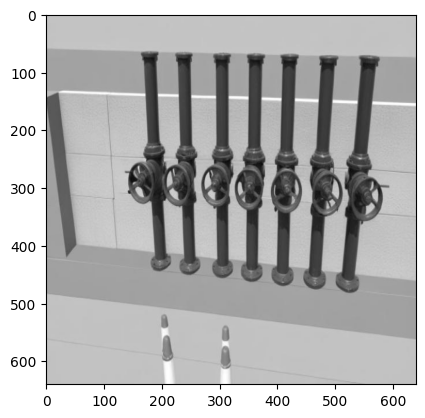

In [49]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/kaggle/input/datasets/tareqalhmiedat/water-pipes-dataset/train/images/024dbfb149c4472e8e106908afb704c9_aug10_jpg.rf.8af93336688783d70979e7e2d67a6fc6.jpg')

plt.imshow(img)
plt.show()

In [50]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [52]:
import os

for root, dirs, files in os.walk('/kaggle/input/water-pipes-dataset'):
    print(root)

print("hello world!")

hello world!


In [55]:
import os
import random
import shutil

# Paths
train_images = "/kaggle/input/water-pipes-dataset/train/images"
train_labels = "/kaggle/input/water-pipes-dataset/train/labels"

# New folders
os.makedirs("/kaggle/working/dataset/train/images", exist_ok=True)
os.makedirs("/kaggle/working/dataset/train/labels", exist_ok=True)
os.makedirs("/kaggle/working/dataset/valid/images", exist_ok=True)
os.makedirs("/kaggle/working/dataset/valid/labels", exist_ok=True)

# Image list
images = [f for f in os.listdir(train_images)
          if f.endswith((".jpg", ".jpeg", ".png"))]

random.shuffle(images)

# 80-20 split
split = int(len(images) * 0.8)

train_set = images[:split]
valid_set = images[split:]

# Copy train
for img in train_set:
    shutil.copy(
        os.path.join(train_images, img),
        "/kaggle/input/datasets/tareqalhmiedat/water-pipes-dataset/train"
    )

    label = os.path.splitext(img)[0] + ".txt"

    if os.path.exists(os.path.join(train_labels, label)):
        shutil.copy(
            os.path.join(train_labels, label),
            "/kaggle/input/datasets/tareqalhmiedat/water-pipes-dataset/train/labels"
        )

# Copy validation
for img in valid_set:
    shutil.copy(
        os.path.join(train_images, img),
        "/kaggle/working/dataset/valid/images"
    )

    label = os.path.splitext(img)[0] + ".txt"

    if os.path.exists(os.path.join(train_labels, label)):
        shutil.copy(
            os.path.join(train_labels, label),
            "/kaggle/working/dataset/valid/labels"
        )

print("Done")
print("Training Images:", len(train_set))
print("Validation Images:", len(valid_set))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/water-pipes-dataset/train/images'